# Diabates Prediction using Artificial Neural Network (TensorFlow)
This notebook builds an ANN model to predict used car prices using TensorFlow.
Steps followed:
1. Read Data
2. Display Data
3. Basic Data Analysis
4. Correlation Analysis
5. Apply Min-Max Scaling
6. Create Neural Network Model
7. Display Model Architecture
8. Display Weight Matrices
9. Train Model with Validation Data
10. Plot Training Loss and Accuracy

## 1. Import Required Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## 2. Read Dataset

In [41]:
# Load dataset
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Display Data and Basic Data Analysis

In [42]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [43]:
df.shape

(768, 9)

In [44]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [45]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 4. Correlation Analysis

In [46]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [47]:
# multi variate analysis
cor_matrix=df.corr(numeric_only=True)
cor_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


<Axes: >

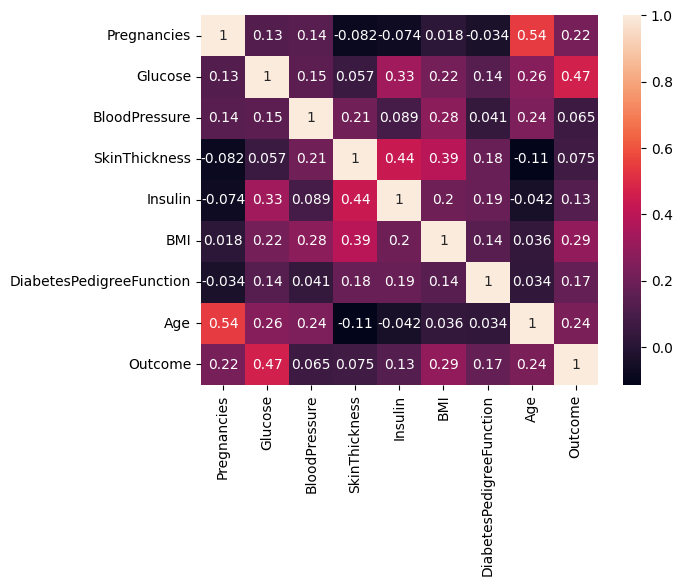

In [48]:
sns.heatmap(data=cor_matrix,annot=True)

In [49]:
df.drop(columns=['BloodPressure','SkinThickness'],axis=1,inplace=True)

In [50]:
df.head()

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,0,33.6,0.627,50,1
1,1,85,0,26.6,0.351,31,0
2,8,183,0,23.3,0.672,32,1
3,1,89,94,28.1,0.167,21,0
4,0,137,168,43.1,2.288,33,1


## 5. Feature Scaling using Min-Max Scaler

In [51]:
# Separate features and target
X = df.drop('Outcome', axis=1)

In [52]:
X

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,0,33.6,0.627,50
1,1,85,0,26.6,0.351,31
2,8,183,0,23.3,0.672,32
3,1,89,94,28.1,0.167,21
4,0,137,168,43.1,2.288,33
...,...,...,...,...,...,...
763,10,101,180,32.9,0.171,63
764,2,122,0,36.8,0.340,27
765,5,121,112,26.2,0.245,30
766,1,126,0,30.1,0.349,47


In [53]:
y = df['Outcome']
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [54]:
"""
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)"""

'\nscaler = MinMaxScaler()\n\nX_scaled = scaler.fit_transform(X)'

In [55]:

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train test split with scaled data
"""X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)"""

'X_train, X_test, y_train, y_test = train_test_split(\n    X_scaled, y, test_size=0.2, random_state=42\n)'

## 6. Create Artificial Neural Network Model

In [56]:
X_train

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84,0,0.0,0.304,21
618,9,112,0,28.2,1.282,50
346,1,139,83,28.7,0.654,22
294,0,161,0,21.9,0.254,65
231,6,134,370,46.2,0.238,46
...,...,...,...,...,...,...
71,5,139,140,28.6,0.411,26
106,1,96,0,22.4,0.207,27
270,10,101,0,45.6,1.136,38
435,0,141,0,42.4,0.205,29


In [57]:
X_train.shape

(614, 6)

In [58]:
X_train.shape[1]

6

In [59]:
"""from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()"""

from sklearn.preprocessing import MinMaxScaler

x_scaler = MinMaxScaler()

X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

In [60]:
"""from sklearn.preprocessing import MinMaxScaler

y_scaler = MinMaxScaler()

y_train = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test = y_scaler.transform(y_test.values.reshape(-1,1))"""

'from sklearn.preprocessing import MinMaxScaler\n\ny_scaler = MinMaxScaler()\n\ny_train = y_scaler.fit_transform(y_train.values.reshape(-1,1))\ny_test = y_scaler.transform(y_test.values.reshape(-1,1))'

In [61]:
input_layer=layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],))

c:\Users\nilay\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
hidden_layer_1=layers.Dense(16, activation='relu')

In [63]:
output_layer=layers.Dense(1)

In [64]:
model = keras.Sequential([
    input_layer,
    hidden_layer_1,
    output_layer
])


"""model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])"""

"model = keras.Sequential([\n    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),\n    layers.Dense(16, activation='relu'),\n    layers.Dense(1)\n])"

## 7. Display Model Architecture

In [65]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Display Weight Matrices and Their Dimensions

In [66]:
model.layers

[<Dense name=dense_3, built=True>,
 <Dense name=dense_4, built=True>,
 <Dense name=dense_5, built=True>]

In [67]:
model.layers[0]

<Dense name=dense_3, built=True>

In [68]:
model.layers[0].get_weights()

[array([[ 0.0990791 , -0.21224803,  0.1650388 , -0.07506096, -0.27942157,
         -0.24683088, -0.08785465, -0.3586261 ,  0.22989759,  0.27029017,
          0.38399693, -0.0594722 , -0.16320258, -0.13352847,  0.03912905,
          0.2518771 ,  0.34960714,  0.2692909 , -0.14914943, -0.33792037,
          0.23240164, -0.288508  , -0.19673327,  0.24758735, -0.27491054,
          0.36655244, -0.3470905 , -0.30953053, -0.01519901,  0.07921559,
          0.08882618,  0.05018657],
        [ 0.35628173, -0.06458247, -0.09570521, -0.05404788,  0.03462663,
         -0.21131505,  0.35373166,  0.23116282, -0.24487501,  0.2806444 ,
          0.3341969 ,  0.39411154, -0.16376787, -0.02736685,  0.36650202,
         -0.15098356,  0.37837318,  0.3823801 , -0.05829102, -0.22816268,
         -0.15926015,  0.27315012,  0.38948026,  0.06386939,  0.10257116,
          0.15069792, -0.3006065 , -0.25248352, -0.16135377,  0.05358407,
          0.11353186, -0.2919641 ],
        [-0.2147437 ,  0.19732955,  0.33

In [69]:
model.layers[0].get_weights()[0].shape

(6, 32)

In [70]:
model.layers[1].get_weights()[0].shape

(32, 16)

In [71]:
model.layers[2].get_weights()[0].shape

(16, 1)

In [72]:
for layer in model.layers:
    weights = layer.get_weights()
    if weights:
        print("Layer:", layer.name)
        print("Weight Matrix Shape:", weights[0].shape)
        print("Bias Shape:", weights[1].shape)
        print()

Layer: dense_3
Weight Matrix Shape: (6, 32)
Bias Shape: (32,)

Layer: dense_4
Weight Matrix Shape: (32, 16)
Bias Shape: (16,)

Layer: dense_5
Weight Matrix Shape: (16, 1)
Bias Shape: (1,)



## 9. Compile and Train Model

| Component    | Purpose                                |
| ------------ | -------------------------------------- |
| Loss (MSE)   | Used by the model to learn             |
| Metric (RMSE) | Used by humans to evaluate performance |

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

"""
loss = 'binary_crossentropy'

Appropriate for problems with two classes (0 or 1).
Measures the difference between predicted probability and actual label.

"""

In [75]:
#mini-batch
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,   # mini batch
    validation_data=(X_test, y_test)
)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6321 - loss: 0.6594 - val_accuracy: 0.6364 - val_loss: 0.6634
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6287 - loss: 0.6460 - val_accuracy: 0.6429 - val_loss: 0.6491
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6939 - loss: 0.5897 - val_accuracy: 0.6494 - val_loss: 0.6415
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6571 - loss: 0.6127 - val_accuracy: 0.6494 - val_loss: 0.6364
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6585 - loss: 0.6084 - val_accuracy: 0.6623 - val_loss: 0.6323


In [168]:
#SGD
"""history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=1,     # one sample at a time
    validation_data=(X_test, y_test)
)"""

'history = model.fit(\n    X_train,\n    y_train,\n    epochs=50,\n    batch_size=1,     # one sample at a time\n    validation_data=(X_test, y_test)\n)'

In [169]:
#Batch Gradient Descent
"""history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=len(X_train),
    validation_data=(X_test, y_test)
)"""

'history = model.fit(\n    X_train,\n    y_train,\n    epochs=50,\n    batch_size=len(X_train),\n    validation_data=(X_test, y_test)\n)'

## 10. Plot Training Loss and Accuracy

In [76]:
history.history

{'accuracy': [0.6579804420471191,
  0.6579804420471191,
  0.6596091389656067,
  0.662866473197937,
  0.6693810820579529],
 'loss': [0.6395930051803589,
  0.6195180416107178,
  0.6102864146232605,
  0.6049359440803528,
  0.6013840436935425],
 'val_accuracy': [0.6363636255264282,
  0.6428571343421936,
  0.649350643157959,
  0.649350643157959,
  0.6623376607894897],
 'val_loss': [0.663428544998169,
  0.6490799188613892,
  0.6414872407913208,
  0.636358380317688,
  0.6323009133338928]}

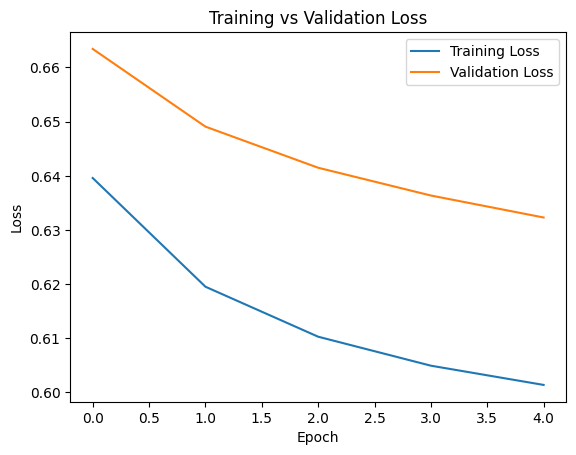

In [77]:
plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

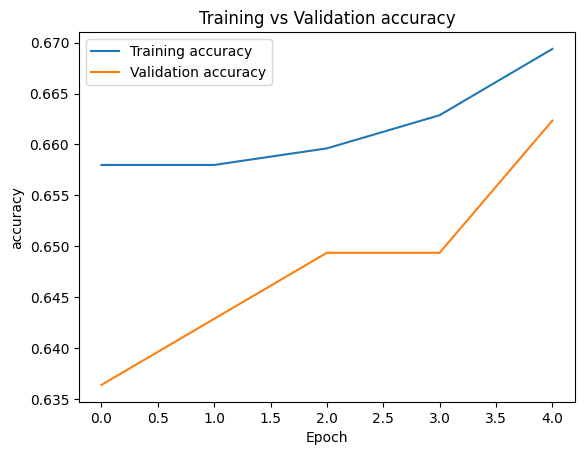

In [79]:
plt.figure()

plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')

plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.title("Training vs Validation accuracy")
plt.legend()

plt.show()

In [82]:
import numpy as np

y_pred_prob = model.predict(X_test)
y_pred_prob[0:5]


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


array([[0.3125424 ],
       [0.31769973],
       [0.29143232],
       [0.25733587],
       [0.3108607 ]], dtype=float32)

In [175]:
y_pred_actual = y_scaler.inverse_transform(y_pred_scaled)
y_pred_actual[0:5]

array([[217399.89],
       [208891.64],
       [252174.5 ],
       [236766.98],
       [250636.06]], dtype=float32)

In [83]:
# Apply threshold
y_pred = (y_pred_prob > 0.29).astype(int)
y_pred[0:5]

array([[1],
       [1],
       [1],
       [0],
       [1]])

In [84]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5064935064935064


In [85]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[34, 65],
       [11, 44]], dtype=int64)